# The Demo of $S^2$Generator for Series-Symbol Data Generation

Time series data serves as the external manifestation of complex dynamical systems. This method aims to generate diverse complex systems represented by symbolic expressions $f(\cdot)$ — through unconstrained construction. It simultaneously generates excitation time series $X \in \mathbb{R} ^ {M \times L}$, which are then fed into the complex systems to produce their responses $Y=f(X) \in \mathbb{R} ^ {N \times L}$. Here, $M$, $N$ and $L$ denote the number of input channels, output channels, and series length, respectively.

**Note: Because the values of the stimulus time series can inflate or fall outside the domain of complex systems, the following examples may not work if your Python version and library version are inconsistent with ours. In this case, please adjust the random seed value in the random number generator.**

In [1]:
import numpy as np
import sys
import os

sys.path.append(os.path.abspath(".."))

# Importing data generators, parameter controllers and visualization functions
from s2generator.symbol import SeriesSymbolGenerator, SeriesParams, SymbolParams
from s2generator.utils import plot_symbol_series
from s2generator import print_hello

print_hello()

Hello, S2Generator!
Version: 0.0.12
This is a Python package for generating time series data with symbolic representations.
For more information, please visit: https://github.com/wwhenxuan/S2Generator

   _____   ___     _____                                        _                  
  / ____| |__ \   / ____|                                      | |                 
 | (___      ) | | |  __    ___   _ __     ___   _ __    __ _  | |_    ___    _ __ 
  \___ \    / /  | | |_ |  / _ \ | '_ \   / _ \ | '__|  / _` | | __|  / _ \  | '__|
  ____) |  / /_  | |__| | |  __/ | | | | |  __/ | |    | (_| | | |_  | (_) | | |   
 |_____/  |____|  \_____|  \___| |_| |_|  \___| |_|     \__,_|  \__|  \___/  |_|                                   



In [2]:
# Adjust the parameters here
# Create a parameter controls the generation of the excitation time series
series_params = SeriesParams()

# Create a parameter controls the generation of the symbolic expression (complex systems)
symbol_params = SymbolParams()

The core of the $S^2$ data generation mechanism is to randomly construct a large number of symbolic expressions (complex systems) $f(\cdot)$ and stimulus time series $X$, and obtain the response of the complex system by inputting the stimulus into the complex system:
$$
Y = f(X)
$$
where, the sampling multivariate time series $X = \left [ x_1, x_2, \cdots, x_m \right ]  \in \mathbb{R}^{M \times L}$ and the generated multivariate time series $Y = \left [ y_1, y_2, \cdots, y_m \right ]  \in \mathbb{R}^{N \times L}$. $M$ and $N$ are the input and output dimension for the time series, $L$ is the length of points of the time series data.

After constructing the input parameters, we can complete this process end-to-end by creating a data generation object and executing the `run` method.

(-15.7 add (((-84.1 mul rand) sub (0.388 mul abs((-89.8 add (0.455 mul x_0))))) mul log(((7.72 mul sqrt((5.56 add (9.58 mul x_0)))) sub (-7.03 mul abs((0.702 add (7.49 mul x_0))))))))


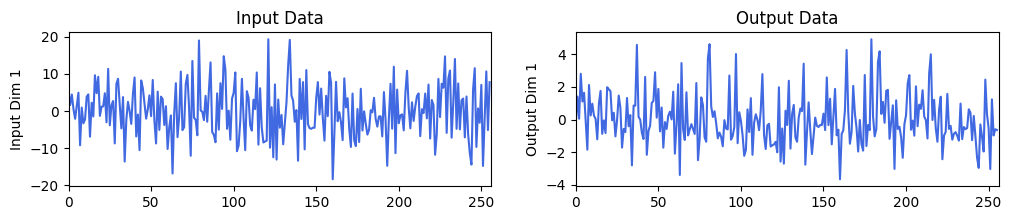

In [6]:
# Create an instance
generator = SeriesSymbolGenerator(
    series_params=series_params, symbol_params=symbol_params
)

# Creating a random number object
rng = np.random.RandomState(42)

# Start generating symbolic expressions, sampling and generating series
trees, x, y = generator.run(
    rng, input_dimension=1, output_dimension=1, n_inputs_points=256
)
# Print the expressions
print(trees)

# Visualize the time series
fig = plot_symbol_series(x, y)

(8.77 add ((-0.736 mul (tan((5.97 add (0.73 mul x_1))) mul ((-2.56 mul sin((-7.85 add (0.1 mul x_0)))) sub (0.163 mul sin((8.44 add (0.667 mul x_1))))))) add (4.85 mul rand))) | (-1.3 add ((-2.8 mul ((-0.375 add (-0.275 mul x_1)))**2) add (0.4 mul x_0)))


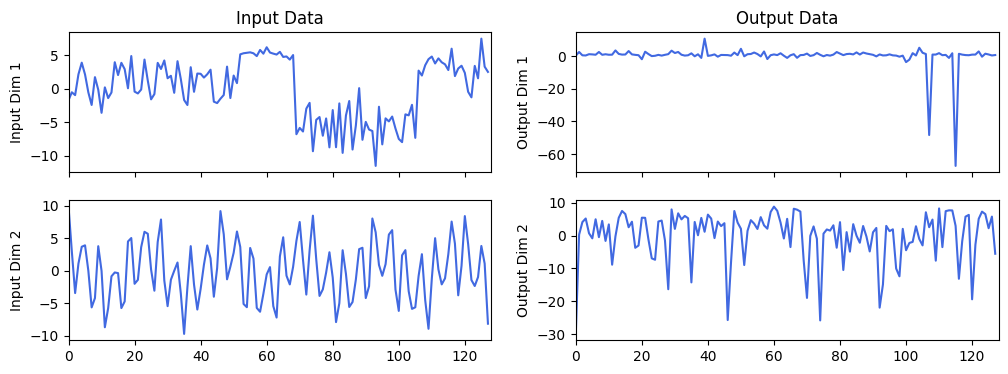

In [9]:
# Try to generate the 2-channels and longer time series
trees, x, y = generator.run(
    rng,
    input_dimension=2,
    output_dimension=2,
    n_inputs_points=128,
    output_normalize="z-score",
)
print(trees)
fig = plot_symbol_series(x, y)

(-0.865 add (((-11.7 mul x_2) sub ((-0.433 mul rand) add (-0.027 mul x_2))) mul (((-14.6 mul x_1) sub (-88.7 mul x_1)) mul x_1))) | (-0.78 add (-0.889 mul x_0)) | (-84.0 add ((-0.148 mul (x_2 mul x_2)) add (-1.15 mul x_1)))


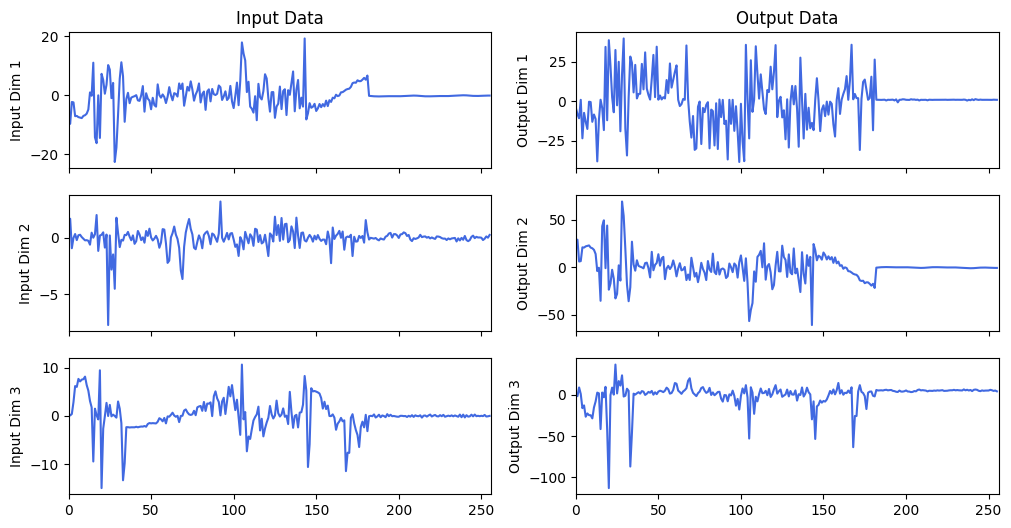

In [11]:
# Try to generate the 3-channels time series
trees, x, y = generator.run(
    rng,
    input_dimension=3,
    output_dimension=3,
    n_inputs_points=256,
    output_normalize="z-score",
)
print(trees)
fig = plot_symbol_series(x, y)

In [6]:
# Save the plotting time series
fig.savefig("../images/ID3_OD3.jpg", dpi=300, bbox_inches="tight")